# Hypothesis Testing and Statistical Analysis

In [3]:
import pandas as pd
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt 
import seaborn as sns
import pingouin

In [4]:
orders = pd.read_csv('C:/Users/Adity/Desktop/Aditya/Super Store Data/CSV/Orders csv.csv')
returns = pd.read_csv('C:/Users/Adity/Desktop/Aditya/Super Store Data/CSV/Return csv.csv')
users = pd.read_csv('C:/Users/Adity/Desktop/Aditya/Super Store Data/CSV/User csv.csv')

In [5]:
orders.head()

,Row ID,Order Priority,Discount,Unit Price,Shipping Cost,Customer ID,Customer Name,Ship Mode,Customer Segment,Product Category,...,Product Base Margin,Country,Region,State or Province,Order Date,Ship Date,Profit,Quantity ordered new,Sales,Order ID
0,20847,High,0.01,2.84,0.93,3,Bonnie Potter,Express Air,Corporate,Office Supplies,...,0.54,United States,West,Washington,2015-01-07,2015-01-08,4.56,4,13.01,88522
1,20228,Not Specified,0.02,500.98,26.00,5,Ronnie Proctor,Delivery Truck,Home Office,Furniture,...,0.60,United States,West,California,2015-06-13,2015-06-15,4390.37,12,6362.85,90193
2,21776,Critical,0.06,9.48,7.29,11,Marcus Dunlap,Regular Air,Home Office,Furniture,...,0.45,United States,East,New Jersey,2015-02-15,2015-02-17,-53.81,22,211.15,90192
3,24844,Medium,0.09,78.69,19.99,14,Gwendolyn F Tyson,Regular Air,Small Business,Furniture,...,0.43,United States,Central,Minnesota,2015-05-12,2015-05-14,803.47,16,1164.45,86838
4,24846,Medium,0.08,3.28,2.31,14,Gwendolyn F Tyson,Regular Air,Small Business,Office Supplies,...,0.56,United States,Central,Minnesota,2015-05-12,2015-05-13,-24.03,7,22.23,86838


# <u> Data Cleaning <u>

In [6]:
orders['Order Priority'] = orders['Order Priority'].str.strip()

In [7]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1952 entries, 0 to 1951
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Row ID                1952 non-null   int64  
 1   Order Priority        1952 non-null   object 
 2   Discount              1952 non-null   float64
 3   Unit Price            1952 non-null   float64
 4   Shipping Cost         1952 non-null   float64
 5   Customer ID           1952 non-null   int64  
 6   Customer Name         1952 non-null   object 
 7   Ship Mode             1952 non-null   object 
 8   Customer Segment      1952 non-null   object 
 9   Product Category      1952 non-null   object 
 10  Product Sub-Category  1952 non-null   object 
 11  Product Base Margin   1936 non-null   float64
 12  Country               1952 non-null   object 
 13  Region                1952 non-null   object 
 14  State or Province     1952 non-null   object 
 15  Order Date           

In [8]:
orders['Order Date'] = pd.to_datetime(orders['Order Date'])
orders['Ship Date'] = pd.to_datetime(orders['Ship Date'])

In [9]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1952 entries, 0 to 1951
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Row ID                1952 non-null   int64         
 1   Order Priority        1952 non-null   object        
 2   Discount              1952 non-null   float64       
 3   Unit Price            1952 non-null   float64       
 4   Shipping Cost         1952 non-null   float64       
 5   Customer ID           1952 non-null   int64         
 6   Customer Name         1952 non-null   object        
 7   Ship Mode             1952 non-null   object        
 8   Customer Segment      1952 non-null   object        
 9   Product Category      1952 non-null   object        
 10  Product Sub-Category  1952 non-null   object        
 11  Product Base Margin   1936 non-null   float64       
 12  Country               1952 non-null   object        
 13  Region            

In [10]:
orders.describe()

,Row ID,Discount,Unit Price,Shipping Cost,Customer ID,Product Base Margin,Order Date,Ship Date,Profit,Quantity ordered new,Sales,Order ID
count,1952.000000,1952.000000,1952.000000,1952.000000,1952.000000,1936.000000,1952,1952,1952.000000,1952.000000,1952.000000,1952.000000
mean,19916.479508,0.048975,109.079221,12.968151,1735.376537,0.515186,2015-03-29 01:21:08.852459008,2015-03-30 23:55:34.426229248,114.793858,12.944672,985.828832,82365.924180
min,64.000000,0.000000,1.140000,0.490000,3.000000,0.350000,2015-01-01 00:00:00,2015-01-02 00:00:00,-16476.840000,1.000000,2.250000,359.000000
25%,19121.000000,0.020000,6.480000,3.230000,875.000000,0.380000,2015-02-11 00:00:00,2015-02-13 00:00:00,-84.487500,5.000000,58.807500,86767.750000
50%,21164.500000,0.050000,20.990000,6.150000,1738.000000,0.525000,2015-03-27 12:00:00,2015-03-29 00:00:00,1.480000,10.000000,202.395000,88376.000000
75%,23483.250000,0.080000,100.972500,14.362500,2578.250000,0.590000,2015-05-15 00:00:00,2015-05-16 00:00:00,116.202500,16.000000,802.945000,89957.000000
max,26389.000000,0.210000,6783.020000,164.730000,3403.000000,0.850000,2015-06-30 00:00:00,2015-07-08 00:00:00,9228.230000,167.000000,45737.330000,91586.000000
std,5957.595627,0.031378,393.481301,17.414631,991.078006,0.137055,NaN,NaN,1141.112401,13.871565,2559.900167,19042.295798


In [11]:
orders['Month'] = orders['Order Date'].dt.month
orders.head()

,Row ID,Order Priority,Discount,Unit Price,Shipping Cost,Customer ID,Customer Name,Ship Mode,Customer Segment,Product Category,...,Country,Region,State or Province,Order Date,Ship Date,Profit,Quantity ordered new,Sales,Order ID,Month
0,20847,High,0.01,2.84,0.93,3,Bonnie Potter,Express Air,Corporate,Office Supplies,...,United States,West,Washington,2015-01-07,2015-01-08,4.56,4,13.01,88522,1
1,20228,Not Specified,0.02,500.98,26.00,5,Ronnie Proctor,Delivery Truck,Home Office,Furniture,...,United States,West,California,2015-06-13,2015-06-15,4390.37,12,6362.85,90193,6
2,21776,Critical,0.06,9.48,7.29,11,Marcus Dunlap,Regular Air,Home Office,Furniture,...,United States,East,New Jersey,2015-02-15,2015-02-17,-53.81,22,211.15,90192,2
3,24844,Medium,0.09,78.69,19.99,14,Gwendolyn F Tyson,Regular Air,Small Business,Furniture,...,United States,Central,Minnesota,2015-05-12,2015-05-14,803.47,16,1164.45,86838,5
4,24846,Medium,0.08,3.28,2.31,14,Gwendolyn F Tyson,Regular Air,Small Business,Office Supplies,...,United States,Central,Minnesota,2015-05-12,2015-05-13,-24.03,7,22.23,86838,5


# Z-Test Analysis For the month of March

# Did March sales significantly decrease compared to average monthly sales?

In [12]:
# Monthly Sales Analysis
months = orders.groupby('Month')['Sales'].sum().reset_index(drop = True)
months

0    274766.92
1    326101.47
2    271696.67
3    389831.95
4    306572.07
5    355368.80
Name: Sales, dtype: float64

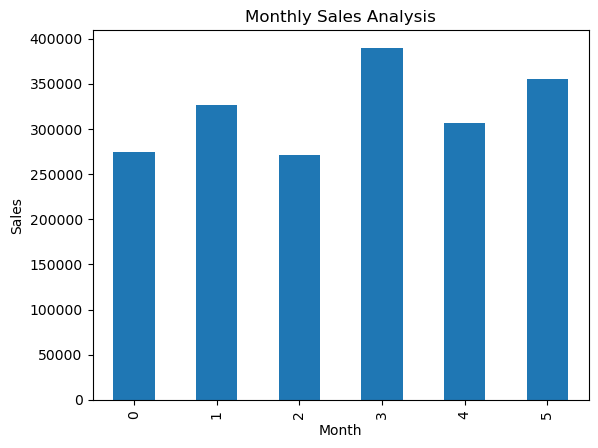

In [13]:
months.plot(kind='bar')

plt.title('Monthly Sales Analysis')
plt.xlabel('Month')
plt.ylabel('Sales')

plt.show()

## Null Hypothesis: March sales are equal to average monthly sales.

## Alternate Hypothesis: March sales are significantly lower than average monthly sales.

In [14]:
march_mean = months[2]

# Monthly Average Sales of the Population 
population_mean = months.mean()

#Standard Error
standard_error = np.std(months, ddof = 0)
standard_error , march_mean, population_mean

(42271.14364311507, np.float64(271696.67), np.float64(320722.98))

In [15]:
zscore = (march_mean - population_mean)/ standard_error
zscore

np.float64(-1.1598056209199623)

In [16]:
# Assuming that the value of Alpha is 10%.
# Now we Calculate the P value 

pvalue = norm.cdf(zscore)
pvalue

np.float64(0.1230639775317261)

### At a 10% significance level, there is not enough statistical evidence to conclude that March sales significantly decreased compared to the average monthly sales.

### Although March sales were lower than the average monthly sales, the difference was not statistically significant based on the calculated p-value (0.123), which is greater than the chosen alpha level of 0.10.

### Therefore, we fail to reject the null hypothesis.

## Limitation

## *** The analysis is based on only six monthly observations. Therefore, the findings should be interpreted as exploratory statistical analysis rather than definitive business proof.

### Visializing the Order Priority Distribution

<Axes: xlabel='Order Priority'>

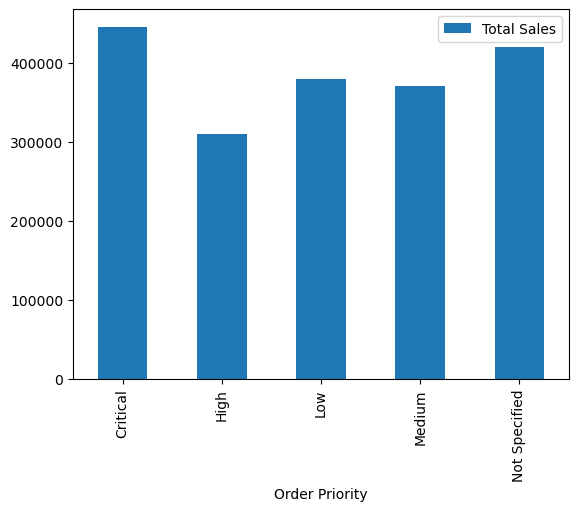

In [17]:
op = orders.groupby('Order Priority')['Sales'].sum().reset_index(name = 'Total Sales')
op.plot(x = 'Order Priority', y = 'Total Sales', kind = 'bar')

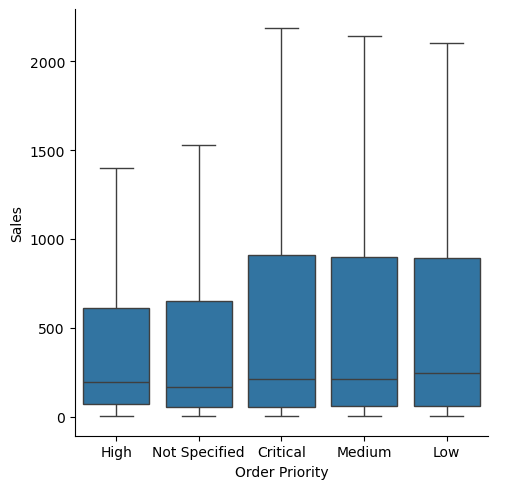

In [18]:
sns.catplot(x = 'Order Priority', y = 'Sales', data = orders, kind = 'box', showfliers = False)

# ANOVA Test on Order Priority

### Null Hypothesis (H₀): There is no significant difference in average sales across the different order priority categories.

### Alternative Hypothesis (H₁): At least one order priority category has a significantly different average sales compared to the others.


In [19]:
pingouin.anova(data = orders, dv = 'Sales', between = 'Order Priority')

,Source,ddof1,ddof2,F,p_unc,np2
0,Order Priority,4,1947,1.001629,0.405403,0.002054


## A one-way ANOVA was conducted to examine whether average sales differed across order priority categories. The analysis showed no statistically significant difference in average sales between the different order priority groups (p = 0.405).

## Therefore, we fail to reject the null hypothesis and conclude that order priority does not appear to have a significant impact on average sales based on the available data.

### Technically, since the ANOVA itself was NOT significant, the pairwise comparisons are not very meaningful statistically.

# <u> ANOVA Test On Region Sales <u>

### Null Hypothesis (H₀): There is no significant difference in average sales across the different regions.

### Alternative Hypothesis (H₁): At least one region has a significantly different average sales compared to the others.

In [20]:
pingouin.anova(data = orders, dv = 'Sales', between = 'Region')

,Source,ddof1,ddof2,F,p_unc,np2
0,Region,3,1948,3.919778,0.008379,0.006


## A one-way ANOVA was conducted to determine whether average sales differed across regions. The analysis revealed a statistically significant difference in average sales between regions (p = 0.008).

## Therefore, the null hypothesis was rejected, indicating that at least one region has a significantly different average sales value compared to the others.

In [21]:
pingouin.pairwise_tests(data = orders, dv = 'Sales', between = 'Region', padjust = 'bonf')

,Contrast,A,B,Paired,Parametric,T,dof,alternative,p_unc,p_corr,p_adjust,BF10,hedges
0,Region,Central,East,False,True,-2.606039,636.470934,two-sided,0.009374,0.056244,bonf,1.964,-0.171828
1,Region,Central,South,False,True,-0.153875,938.462607,two-sided,0.877741,1.000000,bonf,0.072,-0.009785
2,Region,Central,West,False,True,-2.143416,689.665096,two-sided,0.032429,0.194573,bonf,0.67,-0.140655
3,Region,East,South,False,True,2.455203,679.549240,two-sided,0.014330,0.085980,bonf,1.425,0.158603
4,Region,East,West,False,True,0.604714,919.464205,two-sided,0.545518,1.000000,bonf,0.087,0.039305
5,Region,South,West,False,True,-1.976543,738.474589,two-sided,0.048465,0.290790,bonf,0.505,-0.128720


## Although the overall ANOVA test indicated significant differences in average sales across regions, the post-hoc pairwise comparisons using Bonferroni correction did not identify any statistically significant individual region pairs.

## This suggests that while regional variation in sales may exist overall, the differences between specific region pairs were not strong enough to remain significant after adjusting for multiple comparisons.

# <u> Product Category/Sub Category Analysis <u>

In [50]:
pc = orders['Product Category'].value_counts(normalize = True).reset_index(name = 'gt_perc')
pc

,Product Category,gt_perc
0,Office Supplies,0.548668
1,Technology,0.246414
2,Furniture,0.204918


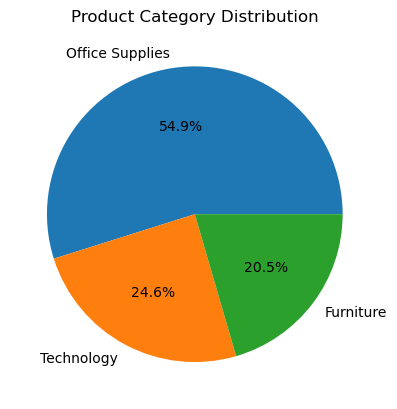

In [57]:
plt.pie(
    pc['gt_perc'],
    labels=pc['Product Category'],
    autopct='%1.1f%%'
)

plt.title('Product Category Distribution')
plt.show()

In [23]:
orders['Product Sub-Category'].value_counts(normalize = True)

Product Sub-Category
Paper                             0.145492
Binders and Binder Accessories    0.102459
Telephones and Communication      0.099385
Office Furnishings                0.094775
Computer Peripherals              0.089139
Pens & Art Supplies               0.082480
Storage & Organization            0.066598
Appliances                        0.051230
Office Machines                   0.048668
Chairs & Chairmats                0.047131
Tables                            0.040984
Labels                            0.036373
Envelopes                         0.028176
Bookcases                         0.022029
Scissors, Rulers and Trimmers     0.018443
Rubber Bands                      0.017418
Copiers and Fax                   0.009221
Name: proportion, dtype: float64

### Null Hypothesis (H₀): There is no significant difference in average sales across the different product categories.

### Alternative Hypothesis (H₁): At least one product category has a significantly different average sales compared to the others.

In [24]:
pingouin.anova(data = orders, dv = 'Sales', between = 'Product Category')

,Source,ddof1,ddof2,F,p_unc,np2
0,Product Category,2,1949,42.379697,9.631727e-19,0.041676


### A one-way ANOVA was conducted to determine whether average sales differed across product categories. The analysis revealed a statistically significant difference in average sales between product categories (p < 0.001).

### Therefore, the null hypothesis was rejected, indicating that at least one product category has a significantly different average sales compared to the others.

In [25]:
pingouin.pairwise_tests(data = orders, dv = 'Sales', between = 'Product Category', padjust = 'bonf')

,Contrast,A,B,Paired,Parametric,T,dof,alternative,p_unc,p_corr,p_adjust,BF10,hedges
0,Product Category,Furniture,Office Supplies,False,True,7.798973,591.063638,two-sided,2.835726e-14,8.507178e-14,bonf,4.164e+11,0.509862
1,Product Category,Furniture,Technology,False,True,0.868425,878.789160,two-sided,3.853989e-01,1.000000e+00,bonf,0.11,0.057657
2,Product Category,Office Supplies,Technology,False,True,-6.058595,663.305941,two-sided,2.301521e-09,6.904564e-09,bonf,3.868e+06,-0.390158


### Overall Interpretation
### Office Supplies behaves differently from the other categories. Furniture and Technology have relatively similar average sales.

# <u> Product Sub-Category <u>

In [26]:
pingouin.anova(data = orders, dv = 'Sales', between = 'Product Sub-Category')

,Source,ddof1,ddof2,F,p_unc,np2
0,Product Sub-Category,16,1935,22.486944,8.684875e-61,0.156786


# <u> Category: Furniture <u>

In [27]:
pc = {}

for i in orders['Product Category'].unique():
    pc[i] = orders[orders['Product Category'] == i]

pingouin.anova(data = pc['Furniture'], dv = 'Sales', between = 'Product Sub-Category')

,Source,ddof1,ddof2,F,p_unc,np2
0,Product Sub-Category,3,396,25.106946,6.854688e-15,0.159808


### A one-way ANOVA was conducted to determine whether average sales differed across Furniture product sub-categories. The analysis revealed a statistically significant difference in average sales among the Furniture sub-categories (p < 0.001).

### Therefore, the null hypothesis was rejected, indicating that at least one Furniture sub-category has significantly different average sales compared to the others.

In [28]:
pingouin.pairwise_tests(data = pc['Furniture'], dv = 'Sales', between = 'Product Sub-Category', padjust = 'bonf')

,Contrast,A,B,Paired,Parametric,T,dof,alternative,p_unc,p_corr,p_adjust,BF10,hedges
0,Product Sub-Category,Bookcases,Chairs & Chairmats,False,True,-0.578079,109.989730,two-sided,5.643924e-01,1.000000e+00,bonf,0.228,-0.094676
1,Product Sub-Category,Bookcases,Office Furnishings,False,True,4.619364,46.974209,two-sided,3.010292e-05,1.806175e-04,bonf,2477.002,1.158057
2,Product Sub-Category,Bookcases,Tables,False,True,0.176171,71.006701,two-sided,8.606612e-01,1.000000e+00,bonf,0.203,0.035457
3,Product Sub-Category,Chairs & Chairmats,Office Furnishings,False,True,5.689264,102.989224,two-sided,1.205140e-07,7.230841e-07,bonf,3.323e+05,0.943842
4,Product Sub-Category,Chairs & Chairmats,Tables,False,True,0.900170,148.624015,two-sided,3.694860e-01,1.000000e+00,bonf,0.241,0.132250
5,Product Sub-Category,Office Furnishings,Tables,False,True,-7.213179,106.942212,two-sided,8.218949e-11,4.931369e-10,bonf,1.2e+09,-1.145844


### Post-hoc pairwise comparisons with Bonferroni correction revealed that Office Furnishings differed significantly in average sales from Bookcases, Chairs & Chairmats, and Tables.

### However, no statistically significant sales differences were observed between Bookcases, Chairs & Chairmats, and Tables, suggesting relatively similar sales performance among these sub-categories.

### The large effect size (partial eta squared = 0.160) indicates that Furniture sub-category is an important contributor to sales variability within the Furniture category.

# <u> Category: Office Supplies <u>

In [29]:
pingouin.anova(data = pc['Office Supplies'], dv = 'Sales', between = 'Product Sub-Category')

,Source,ddof1,ddof2,F,p_unc,np2
0,Product Sub-Category,8,1062,6.686793,1.448586e-08,0.047956


### A one-way ANOVA was conducted to determine whether average sales differed across Office Supplies product sub-categories. The analysis revealed a statistically significant difference in average sales among the sub-categories (p < 0.001).

### Therefore, the null hypothesis was rejected, indicating that at least one Office Supplies sub-category has significantly different average sales compared to the others.

In [30]:
pingouin.pairwise_tests(data = pc['Office Supplies'], dv = 'Sales', between = 'Product Sub-Category', padjust = 'bonf')

,Contrast,A,B,Paired,Parametric,T,dof,alternative,p_unc,p_corr,p_adjust,BF10,hedges
0,Product Sub-Category,Appliances,Binders and Binder Accessories,False,True,-0.351120,295.124911,two-sided,7.257485e-01,1.000000,bonf,0.143,-0.034198
1,Product Sub-Category,Appliances,Envelopes,False,True,3.791044,105.517932,two-sided,2.501637e-04,0.009006,bonf,107.376,0.474380
2,Product Sub-Category,Appliances,Labels,False,True,4.583181,99.965451,two-sided,1.326214e-05,0.000477,bonf,1879.368,0.596876
3,Product Sub-Category,Appliances,Paper,False,True,3.769822,104.069301,two-sided,2.713875e-04,0.009770,bonf,103.504,0.681425
4,Product Sub-Category,Appliances,Pens & Art Supplies,False,True,3.984212,103.445570,two-sided,1.262161e-04,0.004544,bonf,217.713,0.631589
5,Product Sub-Category,Appliances,Rubber Bands,False,True,4.684171,99.964224,two-sided,8.876663e-06,0.000320,bonf,2365.572,0.538967
6,Product Sub-Category,Appliances,"Scissors, Rulers and Trimmers",False,True,3.411319,133.038509,two-sided,8.565791e-04,0.030837,bonf,33.162,0.439961
7,Product Sub-Category,Appliances,Storage & Organization,False,True,-1.680413,202.252577,two-sided,9.442072e-02,1.000000,bonf,0.547,-0.206480
8,Product Sub-Category,Binders and Binder Accessories,Envelopes,False,True,2.834065,204.226827,two-sided,5.057389e-03,0.182066,bonf,6.622,0.226677
9,Product Sub-Category,Binders and Binder Accessories,Labels,False,True,3.318022,199.775710,two-sided,1.077187e-03,0.038779,bonf,24.725,0.272252


### Post-hoc pairwise comparisons with Bonferroni correction revealed statistically significant sales differences across several Office Supplies sub-categories. In particular, Storage & Organization showed consistently different sales performance compared to multiple other sub-categories, indicating that it may represent a distinct sales segment within the Office Supplies category.

### However, several sub-category pairs showed no statistically significant differences, suggesting relatively similar sales behavior among certain Office Supply products.

# <u> Category: Technology <u>

In [31]:
pingouin.anova(data = pc['Technology'], dv = 'Sales', between = 'Product Sub-Category')

,Source,ddof1,ddof2,F,p_unc,np2
0,Product Sub-Category,3,477,31.209728,1.950595e-18,0.164081


### A one-way ANOVA was conducted to examine whether average sales differed across Technology product sub-categories. The analysis revealed a statistically significant difference in average sales among the sub-categories (p < 0.001).

### Therefore, the null hypothesis was rejected, indicating that at least one Technology sub-category has significantly different average sales compared to the others.


In [32]:
pingouin.pairwise_tests(data = pc['Technology'], dv = 'Sales', between = 'Product Sub-Category', padjust = 'bonf')

,Contrast,A,B,Paired,Parametric,T,dof,alternative,p_unc,p_corr,p_adjust,BF10,hedges
0,Product Sub-Category,Computer Peripherals,Copiers and Fax,False,True,-5.480635,17.203207,two-sided,0.000039,0.000234,bonf,7.745e+04,-3.425435
1,Product Sub-Category,Computer Peripherals,Office Machines,False,True,-4.457614,96.345582,two-sided,0.000022,0.000134,bonf,1327.508,-0.757658
2,Product Sub-Category,Computer Peripherals,Telephones and Communication,False,True,-4.255161,357.141410,two-sided,0.000027,0.000160,bonf,595.955,-0.437062
3,Product Sub-Category,Copiers and Fax,Office Machines,False,True,1.967226,35.707857,two-sided,0.056964,0.341784,bonf,1.318,0.369771
4,Product Sub-Category,Copiers and Fax,Telephones and Communication,False,True,4.950961,17.312947,two-sided,0.000115,0.000692,bonf,8514.112,2.818622
5,Product Sub-Category,Office Machines,Telephones and Communication,False,True,3.693970,97.614029,two-sided,0.000364,0.002185,bonf,79.679,0.641550


### Post-hoc pairwise comparisons with Bonferroni correction revealed significant sales differences across most Technology product sub-categories. However, no significant difference was observed between Copiers and Fax and Office Machines, suggesting similar sales performance between these two sub-categories.

### The large effect size (partial eta squared = 0.164) indicates that Technology sub-category is a strong contributor to sales variation within the Technology category.

# <u> Order Return Analysis <u>

In [33]:
returns.head()

,Order ID,Status
0,65,Returned
1,612,Returned
2,614,Returned
3,678,Returned
4,710,Returned


In [34]:
merged = orders.merge(returns, on = 'Order ID', how = 'left')
returns_full = merged[merged['Status'].notna()].reset_index(drop = True)
returns_full.head()

,Row ID,Order Priority,Discount,Unit Price,Shipping Cost,Customer ID,Customer Name,Ship Mode,Customer Segment,Product Category,...,Region,State or Province,Order Date,Ship Date,Profit,Quantity ordered new,Sales,Order ID,Month,Status
0,1950,Medium,0.01,4.91,0.50,117,Linda Weiss,Regular Air,Home Office,Office Supplies,...,West,Washington,2015-04-04,2015-04-06,112.06,47,228.46,13959,4,Returned
1,1951,Medium,0.09,4.00,1.30,117,Linda Weiss,Express Air,Home Office,Office Supplies,...,West,Washington,2015-04-04,2015-04-06,16.79,19,77.61,13959,4,Returned
2,5302,High,0.01,8.33,1.99,308,Glen Caldwell,Regular Air,Small Business,Technology,...,West,Washington,2015-02-14,2015-02-15,10.74,32,280.62,37760,2,Returned
3,1147,Medium,0.08,2.94,0.96,491,Toni Swanson,Regular Air,Consumer,Office Supplies,...,East,New York,2015-05-15,2015-05-17,-2.12,23,66.70,8353,5,Returned
4,2368,Medium,0.00,6.88,2.00,553,Kristine Connolly,Express Air,Home Office,Office Supplies,...,West,California,2015-01-28,2015-01-29,34.07,36,267.53,17155,1,Returned


## Retruns by Product Category

In [35]:
pcr = returns_full['Product Category'].value_counts(normalize = True)
pcr

Product Category
Office Supplies    0.733333
Technology         0.133333
Furniture          0.133333
Name: proportion, dtype: float64

## Retruns by Product Sub Category

### Office Supplies

In [36]:
os = returns_full[returns_full['Product Category'] == 'Office Supplies']['Product Sub-Category'].value_counts(normalize = True)
os

Product Sub-Category
Paper                             0.363636
Pens & Art Supplies               0.181818
Envelopes                         0.181818
Labels                            0.090909
Binders and Binder Accessories    0.090909
Storage & Organization            0.090909
Name: proportion, dtype: float64

### Technology 

In [37]:
tech = returns_full[returns_full['Product Category'] == 'Technology']['Product Sub-Category'].value_counts(normalize = True)
tech

Product Sub-Category
Computer Peripherals    1.0
Name: proportion, dtype: float64

### Furniture

In [38]:
furni = returns_full[returns_full['Product Category'] == 'Furniture']['Product Sub-Category'].value_counts(normalize = True)
furni

Product Sub-Category
Tables                0.5
Chairs & Chairmats    0.5
Name: proportion, dtype: float64

## Regional Distribution

In [39]:
rd = returns_full.groupby('Region')['Row ID'].count()
rd = pd.DataFrame(rd)
rd

,Row ID
Region,
East,7
West,8


# <u> T-Test Analysis on Orders Returned <u>

### Null Hypothesis (H₀): Returned orders have average profit less than or equal to non-returned orders.

### Alternative Hypothesis (H₁): Returned orders have higher average profit than non-returned orders.


In [40]:
merged['Return Status'] = merged['Status'].notna()

pingouin.ttest(x = merged[merged['Return Status'] == True]['Profit'], y = merged[merged['Return Status'] == False]['Profit'], alternative = 'greater')

,T,dof,alternative,p_val,CI95,cohen_d,power
T_test,0.357337,14.768901,greater,0.362947,"[-223.71, inf]",0.050116,0.073311


### An independent one-tailed t-test was conducted to determine whether returned orders had higher average profit than non-returned orders. Although the returned orders showed a slightly higher mean profit, the result was not statistically significant (p = 0.363).

### Therefore, there is insufficient statistical evidence to conclude that returned orders have significantly higher average profit compared to non-returned orders.

### Null Hypothesis (H₀): Returned orders have average sales less than or equal to non-returned orders.

### Alternative Hypothesis (H₁): Returned orders have higher average sales than non-returned orders.


In [41]:
merged['Return Status'] = merged['Status'].notna()

pingouin.ttest(x = merged[merged['Return Status'] == True]['Sales'], y = merged[merged['Return Status'] == False]['Sales'], alternative = 'greater')

,T,dof,alternative,p_val,CI95,cohen_d,power
T_test,1.054881,14.0266,greater,0.154656,"[-1298.1, inf]",0.758936,0.900107


### An independent one-tailed t-test was conducted to examine whether returned orders had higher average sales than non-returned orders. Although returned orders exhibited higher average sales, the result was not statistically significant (p = 0.155).

### However, the large effect size (Cohen’s d = 0.759) suggests that the practical difference between the groups may still be meaningful. This may indicate that higher-value orders are more likely to be returned, although additional data would be required to confirm the relationship statistically.


# <u> Chi-Square Independence Test <u>

## To check wether the Product category are independent with the Region of Sales

In [42]:
grouping = orders.groupby('Region')['Product Category'].value_counts(normalize = True)
grouping

Region   Product Category
Central  Office Supplies     0.556537
         Technology          0.231449
         Furniture           0.212014
East     Office Supplies     0.559072
         Technology          0.232068
         Furniture           0.208861
South    Office Supplies     0.538462
         Technology          0.251131
         Furniture           0.210407
West     Office Supplies     0.538298
         Technology          0.274468
         Furniture           0.187234
Name: proportion, dtype: float64

In [43]:
unstacked = grouping.unstack()
unstacked

Product Category,Furniture,Office Supplies,Technology
Region,,,
Central,0.212014,0.556537,0.231449
East,0.208861,0.559072,0.232068
South,0.210407,0.538462,0.251131
West,0.187234,0.538298,0.274468


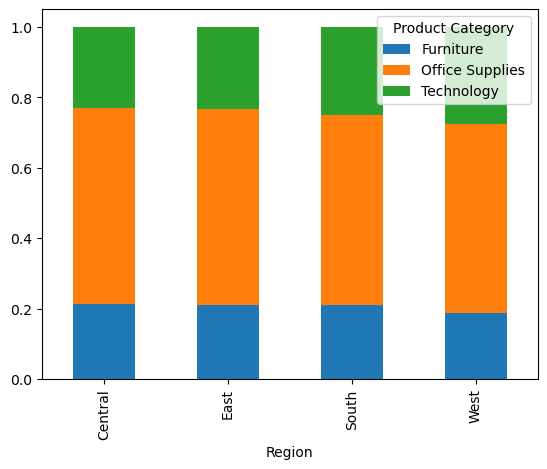

In [44]:
unstacked.plot(kind = 'bar', stacked = True)
plt.show()

## Null Hypothesis (H₀): Product category and sales region are independent.

## Alternative Hypothesis (H₁): Product category and sales region are associated.

In [45]:
expected, observed, stats = pingouin.chi2_independence(data = orders, x = 'Product Category', y = 'Region')
print(stats)

                 test    lambda      chi2  dof      pval    cramer     power
0             pearson  1.000000  3.742127  6.0  0.711526  0.030960  0.138989
1        cressie-read  0.666667  3.736253  6.0  0.712317  0.030936  0.138826
2      log-likelihood  0.000000  3.726016  6.0  0.713696  0.030894  0.138541
3       freeman-tukey -0.500000  3.719644  6.0  0.714554  0.030867  0.138364
4  mod-log-likelihood -1.000000  3.714378  6.0  0.715263  0.030845  0.138218
5              neyman -2.000000  3.707114  6.0  0.716241  0.030815  0.138017


### A Chi-Square Test of Independence was conducted to examine the relationship between product category and sales region. The analysis revealed no statistically significant association between the variables (p = 0.711).

### Additionally, the effect size measured using Cramer’s V (0.030) indicated an extremely weak relationship between product category and region. This suggests that product category distribution remains relatively consistent across sales regions.